In [ ]:
# !pip install lightgbm --quiet

In [ ]:
# # 1. 나눔글꼴 설치
# !apt-get update -qq
# !apt-get install -y fonts-nanum
# !fc-cache -fv

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'NanumGothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 데이터 경로
print(os.getcwd())
path = '/content/drive/MyDrive/파이널 프로젝트/2025_07_07/' #'/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/'
print(os.listdir(path))

/content
['sample_submission.csv', 'Segment_merge_ver_05.parquet', 'Segment_merge_test_ver_05.parquet', '2025_07_09_CatBoost_ABCDvsE_final.csv']


In [5]:
df = pd.read_parquet(path + 'Segment_merge_ver_05.parquet')
df.head()

,기준년월,ID,Segment,소지카드수_이용가능_신용,입회일자_신용,수신거부여부_TM,유효카드수_신용체크,이용가능카드수_신용체크,이용카드수_신용,이용금액_R3M_신용,...,월중평잔_일시불,평잔_일시불_3M,평잔_일시불_6M,인입일수_ARS_R6M,방문후경과월_앱_R6M,불만제기후경과월_R12M,컨택건수_이용유도_TM_R6M,컨택건수_이용유도_EM_R6M,잔액_신판ca최대한도소진율_r6m,변동률_RV일시불평잔
0,201807,TRAIN_000000,D,1,20130101,0,2,2,1,196,...,1503,1791,2440,8,6,12,3,57,0.849842,0.999998
1,201807,TRAIN_000001,E,1,20170801,0,1,1,1,13475,...,4447,3761,2677,0,6,12,2,2,0.851009,1.092698
2,201807,TRAIN_000002,C,1,20080401,0,2,2,1,23988,...,5540,6796,9118,1,0,12,2,12,0.938161,1.006124
3,201807,TRAIN_000003,D,2,20160501,0,3,3,1,3904,...,606,772,884,10,6,12,2,35,1.135424,0.999998
4,201807,TRAIN_000004,E,1,20180601,0,2,2,0,0,...,0,0,21,0,6,0,7,0,0.000000,0.999998


In [6]:
df.shape

(2400000, 138)

In [12]:
drop_cols = ['기준년월','ID','Segment']
X = df.drop(columns=drop_cols)
y = df['Segment']

In [7]:
test = pd.read_parquet(path +  'Segment_merge_test_ver_05.parquet')#'test_전처리데이터병합.parquet')

In [8]:
test.shape

(600000, 137)

In [9]:
test_drop = test.drop(columns=['기준년월', 'ID'])

In [10]:
# ### test diff columns  check
# diff_cols = ['컨택건수_카드론_TM_B0M', '컨택건수_보험_TM_B0M', '컨택건수_이용유도_인터넷_B0M', '컨택건수_리볼빙_TM_R6M', '컨택건수_부대서비스_TM_R6M', '컨택건수_CA_LMS_R6M', '컨택건수_카드론_EM_R6M', '컨택건수_카드론_청구서_R6M', '컨택건수_CA_청구서_R6M', '컨택건수_채권_B0M']

# for d in diff_cols:
#   if d in df.columns :
#     pass
#   else :
#     print(d)

In [13]:
X_test = test[X.columns]
print(X.shape)
print(X_test.shape)

(2400000, 135)
(600000, 135)


In [ ]:
# X_test.to_parquet(path + 'test_data_prep.parquet')

In [ ]:
# 데이터 분할
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [14]:
print(X.shape)
print(y.shape)

(2400000, 135)
(2400000,)


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

# ------------------------------
# 데이터 로딩 및 분리
# ------------------------------
# X = df.drop(columns='label')
# y = df['label']

# Step 1: E vs not E 이진 분류
y_binary = (y == 'E').astype(int)

# 클래스 비율 확인
n_pos = y_binary.sum()
n_neg = len(y_binary) - n_pos
scale_weight = n_neg / n_pos  # scale_pos_weight 방식

# ------------------------------
# Step 1: E vs not E 분류기 (불균형 개선)
# ------------------------------
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y_binary, test_size=0.2, stratify=y_binary, random_state=42)

clf1 = LGBMClassifier(random_state=42, scale_pos_weight=scale_weight)
clf1.fit(X_train1, y_train1)

pred1 = clf1.predict(X_test1)
print("1단계 (E vs not E):")
print(classification_report(y_test1, pred1))

# ------------------------------
# Step 2: A/B/C/D 분류기 (교차검증 + 튜닝)
# ------------------------------
X_not_E = X[y != 'E']
y_not_E = y[y != 'E']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_not_E, y_not_E, test_size=0.2, stratify=y_not_E, random_state=42)

# 파라미터 후보
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

# 교차검증을 포함한 GridSearchCV
grid_clf2 = GridSearchCV(LGBMClassifier(random_state=42), param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_clf2.fit(X_train2, y_train2)

print("2단계 최적 파라미터:", grid_clf2.best_params_)

clf2 = grid_clf2.best_estimator_

pred2 = clf2.predict(X_test2)
print("2단계 (A/B/C/D):")
print(classification_report(y_test2, pred2))

# ------------------------------
# 계층 예측 함수
# ------------------------------
def hierarchical_predict(X_input):
    X_input = X_input[X.columns]  # feature 일치 보장
    step1_pred = clf1.predict(X_input)

    result = []
    for i, is_E in enumerate(step1_pred):
        if is_E == 1:
            result.append('E')
        else:
            row = X_input.iloc[[i]]
            result.append(clf2.predict(row)[0])
    return result

# 최종 예측 성능 확인
final_preds = hierarchical_predict(X_test1)
print("최종 계층 예측 결과:")
print(classification_report(y.iloc[X_test1.index], final_preds))

[LightGBM] [Info] Number of positive: 1537642, number of negative: 382358
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.567679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 24902
[LightGBM] [Info] Number of data points in the train set: 1920000, number of used features: 135
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800855 -> initscore=1.391648
[LightGBM] [Info] Start training from score 1.391648
1단계 (E vs not E):
              precision    recall  f1-score   support

           0       0.68      0.92      0.78     95590
           1       0.98      0.89      0.93    384410

    accuracy                           0.90    480000
   macro avg       0.83      0.90      0.86    480000
weighted avg       0.92      0.90      0.90    480000

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[LightGBM] [Info] Auto-choosing

In [16]:
import pickle
# 모델 저장
pickle.dump(clf1, open('/content/drive/MyDrive/Colab_Notebooks/LGBM_clf1_E_vsnot_E.pkl', 'wb'))
pickle.dump(clf1, open('/content/drive/MyDrive/Colab_Notebooks/LGBM_grid_clf2_E_vsnot_E.pkl', 'wb'))
pickle.dump(clf1, open('/content/drive/MyDrive/Colab_Notebooks/LGBM_clf2_E_vsnot_E.pkl', 'wb'))

In [19]:
# 나눔고딕 설치
!apt-get update -qq
!apt-get install -y fonts-nanum

# matplotlib에 적용
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 43 not upgraded.


In [24]:
import matplotlib.pyplot as plt
print("현재 설정된 폰트:", plt.rcParams['font.family'])

현재 설정된 폰트: ['NanumGothic']


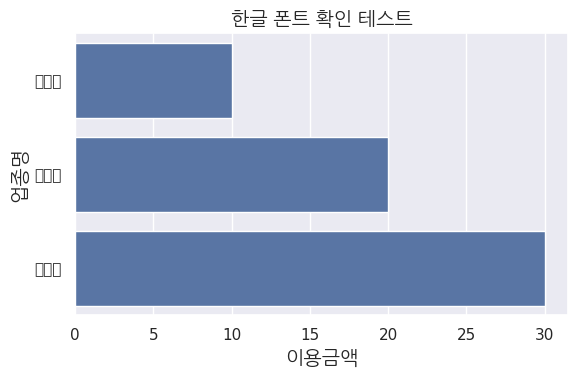

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x=[10, 20, 30], y=['가나다', '라마바', '사아자'])
plt.title('한글 폰트 확인 테스트', fontproperties=font_prop)
plt.xlabel('이용금액', fontproperties=font_prop)
plt.ylabel('업종명', fontproperties=font_prop)
plt.tight_layout()
plt.show()

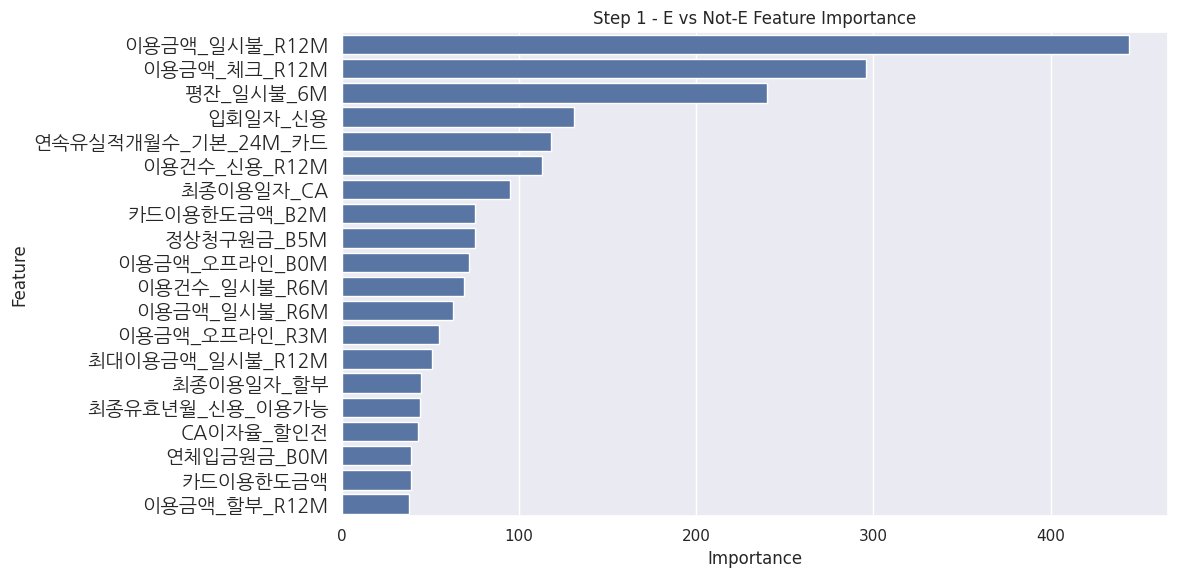

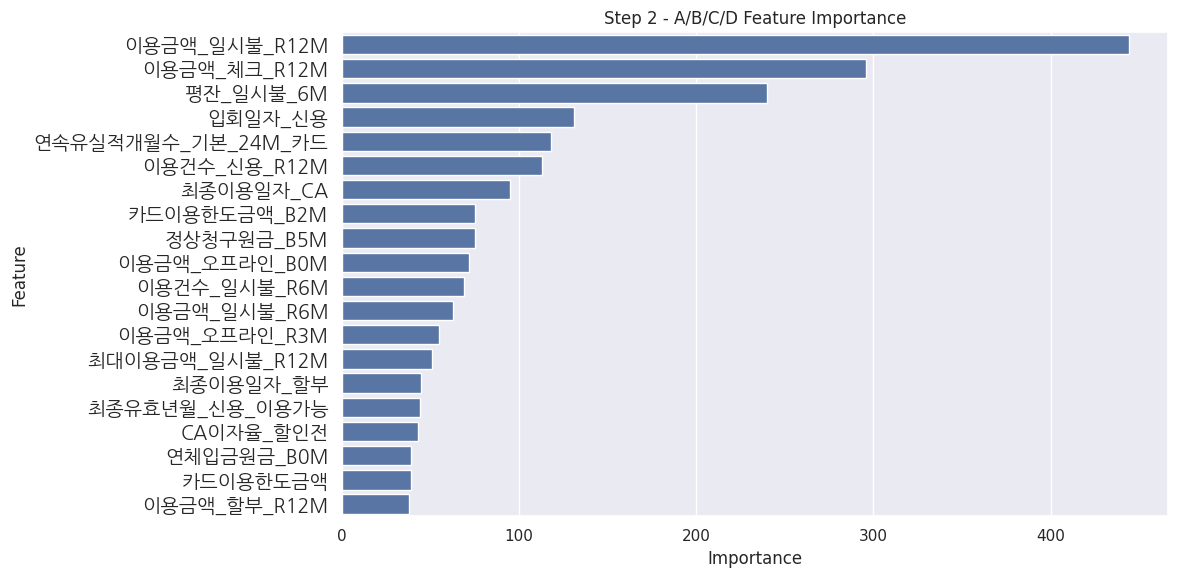

In [33]:
# 나눔고딕 폰트 경로 찾기
# 폰트 경로 및 이름 가져오기
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)

# 기본 폰트로 설정
# plt.rcParams['font.family'] = font_prop.get_name()

# 마이너 경고 무시 (선택)
import warnings
warnings.filterwarnings('ignore')

# matplotlib에 적용
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance 추출
# E와 E가 아닌것 이진분
feat_imp1 = pd.Series(clf1.feature_importances_, index=X.columns).sort_values(ascending=False)



# 시각화 (상위 20개)
plt.figure(figsize=(12, 6))
# 전체 tick label에 폰트 적용
ax1 = sns.barplot(x=feat_imp1[:20], y=feat_imp1.index[:20])
for label in ax1.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.title('Step 1 - E vs Not-E Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab_Notebooks/step1_featimp.png')
plt.show()

# E가 아닌것 다중분류
feat_imp2 = pd.Series(clf2.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
ax2 = sns.barplot(x=feat_imp1[:20], y=feat_imp1.index[:20])
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.title('Step 2 - A/B/C/D Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab_Notebooks/step2_featimp.png')
plt.show()


feat_imp1.to_csv('/content/drive/MyDrive/Colab_Notebooks/E_vs_not_E_step1_feature_importance.csv')
feat_imp2.to_csv('/content/drive/MyDrive/Colab_Notebooks/E_vs_not_E_step2_feature_importance.csv')



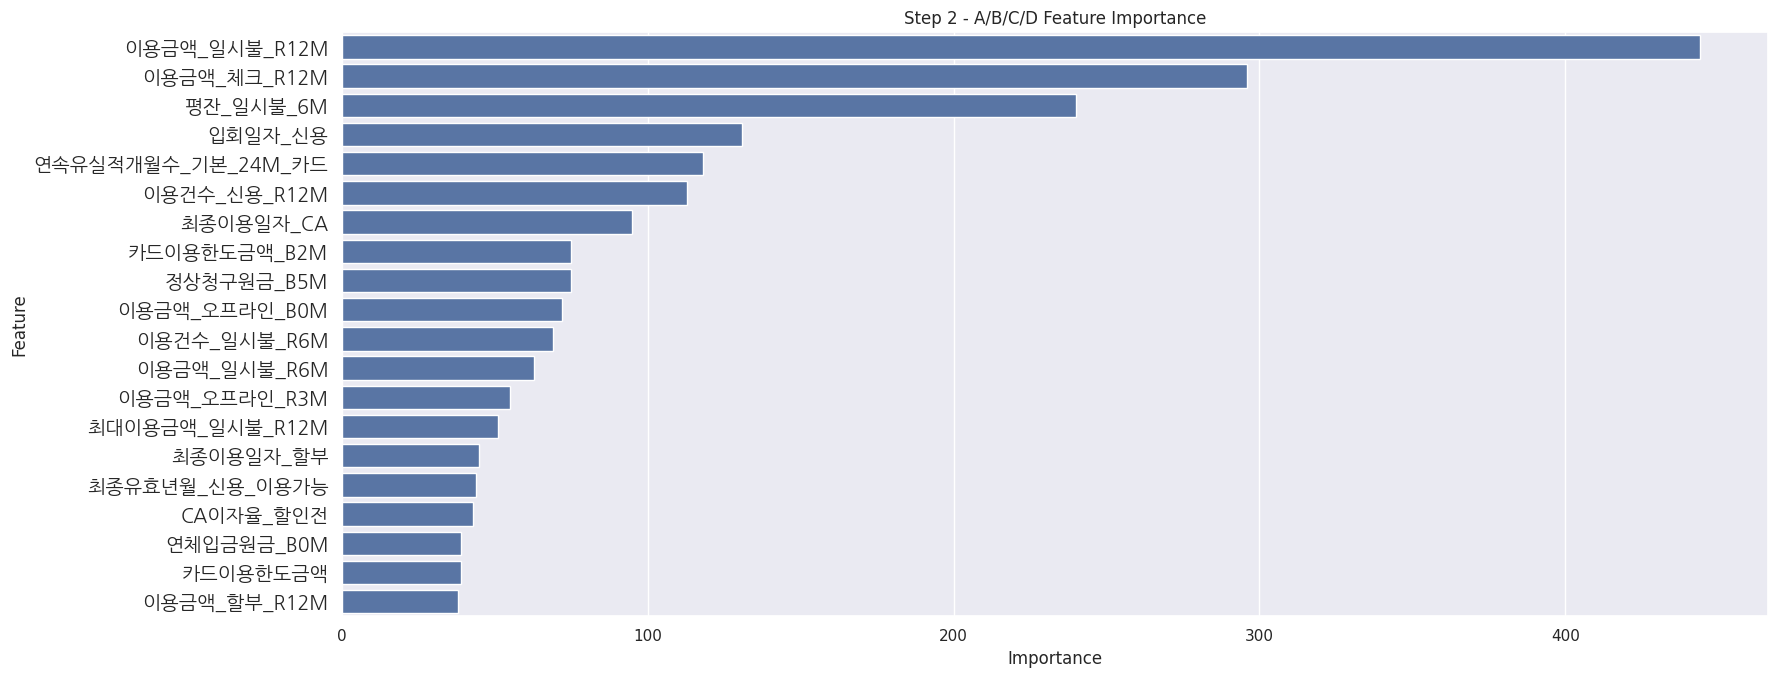

In [37]:
# E가 아닌것 다중분류
feat_imp2 = pd.Series(clf2.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(18, 7))
ax2 = sns.barplot(x=feat_imp1[:20], y=feat_imp1.index[:20])
for label in ax2.get_yticklabels():
    label.set_fontproperties(font_prop)

plt.title('Step 2 - A/B/C/D Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab_Notebooks/step2_featimp.png')
plt.show()


In [38]:
# ------------------------------
# 실제 테스트 데이터 로드
# ------------------------------
# 예시: X_test_real 은 예측에 사용할 실제 테스트셋 (DataFrame), 라벨은 없음
# 컬럼명은 학습 데이터 X와 동일해야 함
# 예: X_test_real = pd.read_csv('your_test_data.csv')

# ------------------------------
# 계층 분류 예측 함수 실행
# ------------------------------
final_pred= hierarchical_predict(X_test)

# ------------------------------
# 예측 결과를 DataFrame으로 저장
# ------------------------------
submission = pd.DataFrame({
    'ID': test.ID,         # 또는 'sample_id' 등 ID 컬럼이 따로 있다면 그걸 사용
    'Segment': final_pred  # 예측된 라벨: A/B/C/D/E
})

# 결과 확인
print(submission.head())

# ------------------------------
# CSV로 저장 (제출용 등)
# ------------------------------
submission.to_csv('/content/drive/MyDrive/Colab_Notebooks/submission_E_vs_not_E.csv', index=False)

           ID Segment
0  TEST_00000       D
1  TEST_00001       E
2  TEST_00002       D
3  TEST_00003       E
4  TEST_00004       E


In [ ]:
submission.Segment.value_counts()

,count
Segment,
E,433095
D,139224
C,27203
B,341
A,137


In [ ]:
submission_unique = submission.groupby('ID')['Segment'].agg(lambda x: x.mode().iloc[0]).reset_index()
submission_unique.Segment.value_counts()

,count
Segment,
E,71551
D,23751
C,4643
B,34
A,21


In [ ]:
origin = submission.Segment.value_counts().reset_index()
dupli = submission_unique.Segment.value_counts().reset_index()

merged = pd.merge(origin,dupli,how='left',on='Segment')
merged['나누기6'] = ( merged.count_x/6)
merged

,Segment,count_x,count_y,나누기6
0,E,433095,71551,72182.500000
1,D,139224,23751,23204.000000
2,C,27203,4643,4533.833333
3,B,341,34,56.833333
4,A,137,21,22.833333


In [ ]:
submission_unique.to_csv('/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/submission_girid_search.csv', index=False)

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from lightgbm import LGBMClassifier
# from sklearn.metrics import classification_report

# # ------------------------------
# # 데이터 예시 로딩
# # ------------------------------
# # df는 feature + target 컬럼을 가진 DataFrame이라고 가정
# # target 컬럼: 'label' — A, B, C, D, E 중 하나
# # feature 컬럼: ['f1', 'f2', ..., 'fn']

# # X, y 분리
# # X = df.drop(columns='label')
# # y = df['label']

# # ------------------------------
# # Step 1: E vs not E 이진 분류
# # ------------------------------
# y_binary = (y == 'E').astype(int)  # E: 1, not E: 0

# X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# clf1 = LGBMClassifier(random_state=42)
# clf1.fit(X_train1, y_train1)

# # 예측
# pred1 = clf1.predict(X_test1)
# print("1단계 (E vs not E) 결과:")
# print(classification_report(y_test1, pred1))

# # ------------------------------
# # Step 2: not E 대상 A/B/C/D 다중 분류
# # ------------------------------
# # not E인 샘플만 추출
# X_not_E = X[y != 'E']
# y_not_E = y[y != 'E']

# X_train2, X_test2, y_train2, y_test2 = train_test_split(X_not_E, y_not_E, test_size=0.2, random_state=42, stratify=y_not_E)

# clf2 = LGBMClassifier(random_state=42)
# clf2.fit(X_train2, y_train2)

# # 예측
# pred2 = clf2.predict(X_test2)
# print("2단계 (A/B/C/D 분류) 결과:")
# print(classification_report(y_test2, pred2))

# # ------------------------------
# # 전체 예측 함수: 계층적으로 결합
# # ------------------------------
# def hierarchical_predict(X_input):
#     step1_pred = clf1.predict(X_input)

#     result = []
#     for i, is_E in enumerate(step1_pred):
#         if is_E == 1:
#             result.append('E')
#         else:
#             result.append(clf2.predict(X_input.iloc[[i]])[0])  # X_input은 DataFrame
#     return result

# # 예시 사용
# final_preds = hierarchical_predict(X_test1)  # 전체 테스트셋에 대한 계층적 예측
# print("최종 계층 분류 결과:")
# print(classification_report(y.iloc[X_test1.index], final_preds))

[LightGBM] [Info] Number of positive: 1537642, number of negative: 382358
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.252421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6647
[LightGBM] [Info] Number of data points in the train set: 1920000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.800855 -> initscore=1.391648
[LightGBM] [Info] Start training from score 1.391648
1단계 (E vs not E) 결과:
              precision    recall  f1-score   support

           0       0.81      0.73      0.76     95590
           1       0.93      0.96      0.94    384410

    accuracy                           0.91    480000
   macro avg       0.87      0.84      0.85    480000
weighted avg       0.91      0.91      0.91    480000

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.038

In [ ]:
X_test1[test.columns]

KeyError: "['기준년월', 'ID'] not in index"

In [ ]:
# ------------------------------
# 실제 테스트 데이터 로드
# ------------------------------
# 예시: X_test_real 은 예측에 사용할 실제 테스트셋 (DataFrame), 라벨은 없음
# 컬럼명은 학습 데이터 X와 동일해야 함
# 예: X_test_real = pd.read_csv('your_test_data.csv')

# ------------------------------
# 계층 분류 예측 함수 실행
# ------------------------------
final_predictions = hierarchical_predict(test_drop)

# ------------------------------
# 예측 결과를 DataFrame으로 저장
# ------------------------------
submission = pd.DataFrame({
    'ID': test.ID,         # 또는 'sample_id' 등 ID 컬럼이 따로 있다면 그걸 사용
    'Segment': final_predictions  # 예측된 라벨: A/B/C/D/E
})

# 결과 확인
print(submission.head())

# ------------------------------
# CSV로 저장 (제출용 등)
# ------------------------------
# submission.to_csv('/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/submission.csv', index=False)

           ID Segment
0  TEST_00000       E
1  TEST_00001       E
2  TEST_00002       D
3  TEST_00003       E
4  TEST_00004       E


In [ ]:
submission[submission['ID'] == 'TEST_34325']

,ID,Segment
34325,TEST_34325,E
134325,TEST_34325,E
234325,TEST_34325,E
334325,TEST_34325,E
434325,TEST_34325,E
534325,TEST_34325,E


In [ ]:
submission[submission['ID'] == 'TEST_99999']

,ID,Segment
99999,TEST_99999,E
199999,TEST_99999,E
299999,TEST_99999,E
399999,TEST_99999,E
499999,TEST_99999,E
599999,TEST_99999,E


In [ ]:
submission.shape

(600000, 2)

In [ ]:
submission[submission.Segment != 'E'].iloc[:100000]

,ID,Segment
2,TEST_00002,D
12,TEST_00012,D
16,TEST_00016,D
32,TEST_00032,D
34,TEST_00034,D
...,...,...
557589,TEST_57589,D
557592,TEST_57592,D
557594,TEST_57594,C
557602,TEST_57602,D


In [ ]:
submission_unique = submission.groupby('ID')['Segment'].agg(lambda x: x.mode().iloc[0]).reset_index()

In [ ]:
submission.Segment.value_counts()

,count
Segment,
E,492726
D,80251
C,26537
A,329
B,157


In [ ]:
submission_unique.Segment.value_counts()

,count
Segment,
E,81713
D,13672
C,4577
A,34
B,4


In [ ]:
submission_unique.to_csv('/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/submission_0707.csv', index=False)

In [ ]:
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## 저장된 데이터 확인
tmp = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/01.like_lion_final_prj/submission.csv')
tmp.head()

,ID,Segment
0,TEST_00000,E
1,TEST_00001,D
2,TEST_00002,E
3,TEST_00003,E
4,TEST_00004,E
